In [43]:
import sklearn
import pandas as pd
import matplotlib as mp

# Why Do we Do Shape Checks ?

We perform the shape check for a dataset to indentify the following ~

1. Understanding dataset size
    - shape : ( rows, columns )
    - Rows : samples( data points )
    - Columns : features ( input variables ) + target

    This helps us dermiting if  ~

    - We have enough data to train a model
    - Weather the dataset is too small

2. Verify the feature count ~
    - Too many features needs dimensionality reduction
    - Too feaw deatures model may underfit

3. Early data issue detection
4. To seperate `X` and `y`properly
5. Memory and performance considerations

In [ ]:
# Load The CSV

data = pd.read_csv("V1.csv")

# ===== Check Details ===== #

data.info()  # Generalized Metadata
data.head()  # First 5 Rows - To Understand The State Of Data

# ===== Check Datatypes ===== #

data.shape  # Get Number Of Rows And Column
data.dtypes  # Get The Datatypes Of The Columns

data["gender"].dtype  # Check Datatype Of Single Column Using ~


<class 'pandas.DataFrame'>
RangeIndex: 6257 entries, 0 to 6256
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              6257 non-null   int64  
 1   gender          6257 non-null   str    
 2   area            5873 non-null   str    
 3   qualification   6257 non-null   str    
 4   income          5856 non-null   float64
 5   marital_status  6257 non-null   int64  
 6   vintage         6257 non-null   int64  
 7   claim_amount    5897 non-null   float64
 8   num_policies    6257 non-null   str    
 9   policy          5885 non-null   str    
 10  type_of_policy  6257 non-null   str    
 11  cltv            6257 non-null   int64  
dtypes: float64(2), int64(4), str(6)
memory usage: 586.7 KB


<StringDtype(storage='python', na_value=nan)>

# Why understanding the dataypes matter ?

Datatypes directly affect preprocessing of the data ~

1. If the datatype is `object` - needs encoding ( categorical / text )
2. If `int`/`float` - we use numberical features
3. `bool` - convert to `0`/`1` based on the data

Since using wrong datatypes to train teh model can break or reduce performance

# Why checking missing values matters ?

Missing values causes errors in training the model also the machine learning algorithms can't automatically handle the missing data so we need to preprocess the data before traning. We generally utilize these missing data filling techniques ~

1. fillinf with statistical data such as mean, median and mode
2. Dropping rows / columns which do not add value to the trained model
3. Imputation techniques

In [9]:
# To Check The Missing values
# This Is Essentially Sum Of Missing Values

data.isnull().sum()
data.isna().sum()

# Check The Total Missing Values In The Dataset

data.isnull().sum().sum()

# Check If Any Missing Values Exsist

data.isnull().values.any()

# Check Rows With Missing Values

data[data.isnull().any(axis=1)]

,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
2,6499,Female,Urban,High School,2.26,1,2,NaN,More than 1,A,Platinum,68076
8,25376,Female,Urban,High School,NaN,0,7,0.0,More than 1,A,Gold,80076
9,76738,Male,NaN,Others,6.62,0,4,4176.0,1,A,Gold,76092
10,7091,Female,NaN,Bachelor,4.04,0,5,0.0,More than 1,A,Gold,104760
18,69405,Male,Rural,Others,9.32,1,5,NaN,More than 1,C,Platinum,288288
...,...,...,...,...,...,...,...,...,...,...,...,...
6241,55514,Female,Urban,High School,8.45,1,5,NaN,More than 1,A,Platinum,69024
6242,6700,Female,Urban,Bachelor,NaN,0,5,7042.0,More than 1,B,Platinum,193800
6246,57154,Female,NaN,Bachelor,4.91,0,5,5590.0,More than 1,A,Silver,69768
6250,40537,Female,Urban,Bachelor,4.28,1,8,8360.0,More than 1,NaN,Platinum,116100


In [ ]:
# Getting Unique Values

data["qualification"].unique()  # Getting The Unique Values With Count
data["qualification"].nunique()  # Getting Only Unique Values Count


3

In [23]:
# Counting Values Of A Column

data["policy"].value_counts()

# Overall Total Values

print()
print(data["claim_amount"].value_counts(dropna=True))

# Values Without NaN / Missing Values

print()
print(data["claim_amount"].value_counts(dropna=False))


# Normalized Vlaues

print()
print(data["claim_amount"].value_counts(normalize=True))



claim_amount
0.0       1209
6324.0       5
3930.0       5
4131.0       5
3915.0       5
          ... 
8360.0       1
6488.0       1
8093.0       1
3902.0       1
2906.0       1
Name: count, Length: 3438, dtype: int64

claim_amount
0.0       1209
NaN        360
6324.0       5
3930.0       5
4131.0       5
          ... 
8360.0       1
6488.0       1
8093.0       1
3902.0       1
2906.0       1
Name: count, Length: 3439, dtype: int64

claim_amount
0.0       0.205020
6324.0    0.000848
3930.0    0.000848
4131.0    0.000848
3915.0    0.000848
            ...   
8360.0    0.000170
6488.0    0.000170
8093.0    0.000170
3902.0    0.000170
2906.0    0.000170
Name: proportion, Length: 3438, dtype: float64


# Indentifying Target Columns

To identify the target columns we need to check on the question since it is the essential part of traning a machine learning model. Based on the given question here are some basic examples we could be asked to do ~

1. “Predict price” → target = `price`
2. “Classify spam” → target = `label` or `is_spam`
3. “Predict survival” → target = `survived`

In [24]:
# To Identify All The Columns We Can Use

data.columns

Index(['id', 'gender', 'area', 'qualification', 'income', 'marital_status',
       'vintage', 'claim_amount', 'num_policies', 'policy', 'type_of_policy',
       'cltv'],
      dtype='str')

# Splitting The Dataset

Once we have identified the target column, one that we need to predict we would split that data from the dastaset and put it as column `y` one the model will essentially predict the values for. The rest of the column would be put as the training set `X` or the columns which the model will use predict the values of `y` for.

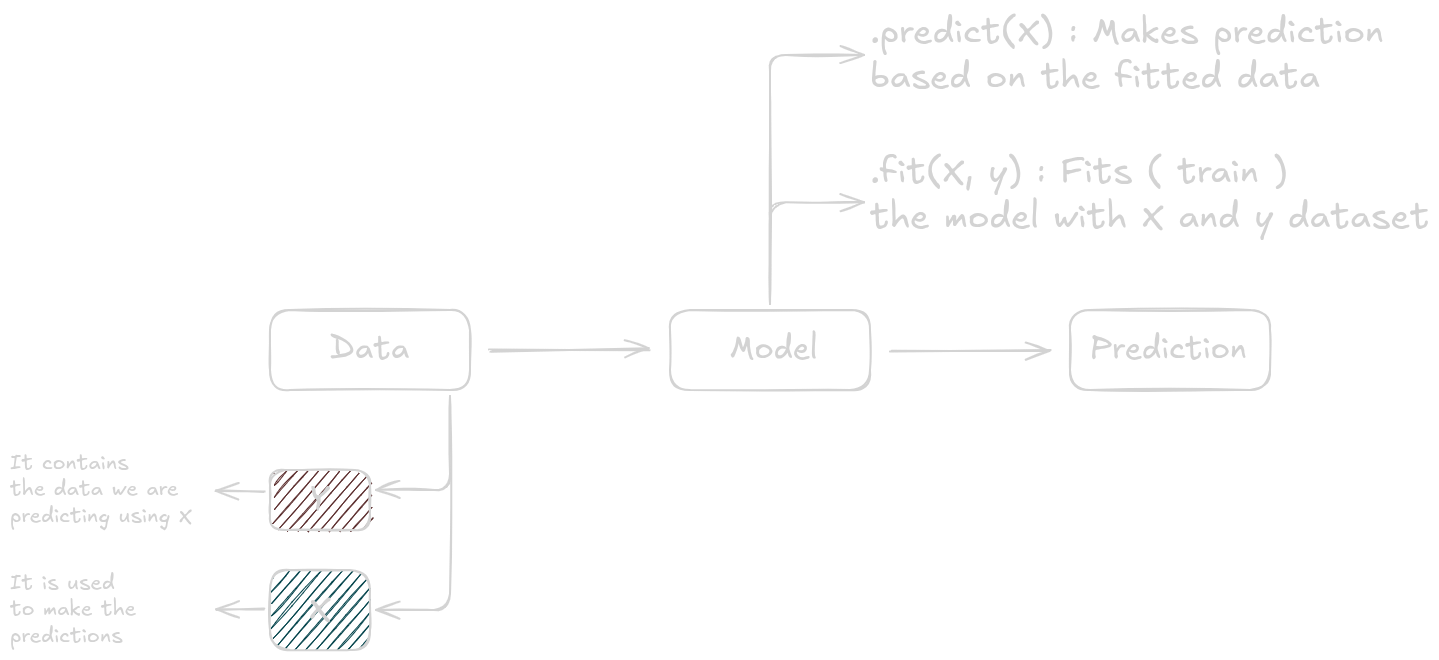

### Improtant Note

Before we move on into splitting the dataset we need to remove the columns that add no value like the `index` or any `serial_number` based column, it just acts as noise for the model and add in trainign errors. Other such columns inlcude timestamp and other future informations.

In [ ]:
# To Drop A Particular Column We Use .drop()

data.drop("id", axis=1) # Telling It Drop Column 1 


,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
0,Male,Urban,High School,42.99,0,0,3849.0,1,A,Platinum,66816
1,Male,Rural,Bachelor,5.33,1,6,3006.0,More than 1,A,Gold,67164
2,Female,Urban,High School,2.26,1,2,NaN,More than 1,A,Platinum,68076
3,Male,Rural,High School,20.29,1,8,2844.0,More than 1,A,Platinum,63276
4,Female,Urban,High School,5.63,0,6,6370.0,More than 1,A,Platinum,245844
...,...,...,...,...,...,...,...,...,...,...,...
6252,Male,Urban,High School,NaN,0,3,6488.0,More than 1,A,Gold,102312
6253,Male,Urban,High School,2.23,0,6,8093.0,More than 1,B,Platinum,105984
6254,Male,Urban,Bachelor,5.55,0,3,3902.0,1,A,Silver,34560
6255,Male,Rural,High School,6.44,1,4,2906.0,More than 1,C,Gold,151296


In [40]:
# To Split The Dataset We First Identify What Are We Trying To Predict And Them Drop Them To y And Rest To X

X = data.drop("cltv", axis=1)
y = data["cltv"]

# Since The Target Value Is Already Mentioned The Split Is Simple ~ y : cltv And X : rest ( except cltv )

print(X.shape)
print(y.shape)

(6257, 11)
(6257,)


# Handling Missing Values

Handling missing values is not just about filling them it depends on data type, distribution, and context. The choices affect model bias, variance, and leakage.